# 01 Data Sources and Sample Inclusion

**Methods mapping:** data sources and sample inclusion.

The retained-sample table is built from curated metadata, depth-QC metadata, and TF003/T10 G-gene haplotype FASTA records. A sample is retained when at least one parsed G-gene haplotype is present; clade, date, location, and depth fields are then joined from metadata.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'config' / 'analysis_config.yaml').exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / 'notebooks'))
import analysis_utils as au
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
rel = lambda path: Path(path).relative_to(ROOT).as_posix()
ROOT


PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes')

In [2]:
DATA_DIR, FIG_DIR = au.step_dirs('01_data_sources_and_sample_inclusion', ROOT)
INPUTS = {
    "metadata": ROOT / "data/metadata/meta_v6_with_season_clade.csv",
    "depth_qc": ROOT / "data/metadata/qualified_samples_depth200_pos90.csv",
    "AU_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1037681_extracted_4652-5617.fasta",
    "US_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1130896_extracted_4652-5617.fasta",
}
OUTPUTS = {
    "retained_sample_metadata": DATA_DIR / "current_T10_sample_metadata.csv",
    "sample_inclusion_summary": DATA_DIR / "sample_inclusion_summary.csv",
    "month_clade_counts": DATA_DIR / "sample_month_clade_counts.csv",
    "figure_png": FIG_DIR / "Fig1AB_sample_month_clade_composition.png",
    "figure_pdf": FIG_DIR / "Fig1AB_sample_month_clade_composition.pdf",
    "figure_svg": FIG_DIR / "Fig1AB_sample_month_clade_composition.svg",
}


def show_paths(title, paths):
    rows = []
    for name, path in paths.items():
        path = Path(path)
        rows.append({"name": name, "relative_path": rel(path), "exists": path.exists()})
    display(Markdown(f"### {title}"))
    display(pd.DataFrame(rows))

for path in OUTPUTS.values():
    Path(path).parent.mkdir(parents=True, exist_ok=True)

show_paths("Input paths", INPUTS)
show_paths("Output paths", OUTPUTS)
DATA_DIR, FIG_DIR


### Input paths

,name,relative_path,exists
0,metadata,data/metadata/meta_v6_with_season_clade.csv,True
1,depth_qc,data/metadata/qualified_samples_depth200_pos90...,True
2,AU_haplotype_fasta,data/input/haplotypes/PRJNA1037681_extracted_4...,True
3,US_haplotype_fasta,data/input/haplotypes/PRJNA1130896_extracted_4...,True


### Output paths

,name,relative_path,exists
0,retained_sample_metadata,data/processed_data/01_data_sources_and_sample_inclus...,True
1,sample_inclusion_summary,data/processed_data/01_data_sources_and_sample_inclus...,True
2,month_clade_counts,data/processed_data/01_data_sources_and_sample_inclus...,True
3,figure_png,results/figures/01_data_sources_and_sample_inc...,True
4,figure_pdf,results/figures/01_data_sources_and_sample_inc...,True
5,figure_svg,results/figures/01_data_sources_and_sample_inc...,True


(PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/data/processed_data/01_data_sources_and_sample_inclusion'),
 PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/results/figures/01_data_sources_and_sample_inclusion'))

## Read Input Tables

I first check the three input tables/files before making the retained-sample table. The haplotype count comes from FASTA headers.


In [3]:
metadata = au.load_metadata(ROOT)
depth_qc = au.load_depth_qc(ROOT)
hap_records = au.load_haplotype_records(ROOT)

input_counts = pd.DataFrame({
    'input_object': ['metadata', 'depth_qc', 'haplotype_fasta_records'],
    'rows': [len(metadata), len(depth_qc), len(hap_records)],
    'samples': [metadata['SampleID'].nunique(), depth_qc['SampleID'].nunique(), hap_records['SampleID'].nunique()],
})
hap_counts = hap_records.groupby(['project', 'SampleID'], as_index=False).agg(n_haplotypes=('SequenceName', 'count'))

display(input_counts)
display(hap_records[['project', 'SampleID', 'SequenceName', 'haplotype_frequency', 'input_fasta']].head())
display(hap_counts.groupby('project', as_index=False).agg(samples=('SampleID', 'nunique'), median_haplotypes=('n_haplotypes', 'median'), max_haplotypes=('n_haplotypes', 'max')))


,input_object,rows,samples
0,metadata,112,112
1,depth_qc,112,112
2,haplotype_fasta_records,218,109


,project,SampleID,SequenceName,haplotype_frequency,input_fasta
0,PRJNA1037681,SRR26779971,PRJNA1037681_SRR26779971_H1_freq0.724469925402...,0.724470,data/input/haplotypes/PRJNA1037681_extracted_4...
1,PRJNA1037681,SRR26779971,PRJNA1037681_SRR26779971_H2_freq0.275530074597...,0.275530,data/input/haplotypes/PRJNA1037681_extracted_4...
2,PRJNA1037681,SRR26779973,PRJNA1037681_SRR26779973_H1_freq0.801246675481247,0.801247,data/input/haplotypes/PRJNA1037681_extracted_4...
3,PRJNA1037681,SRR26779973,PRJNA1037681_SRR26779973_H2_freq0.198753324518...,0.198753,data/input/haplotypes/PRJNA1037681_extracted_4...
4,PRJNA1037681,SRR26779974,PRJNA1037681_SRR26779974_H1_freq0.714021896184...,0.714022,data/input/haplotypes/PRJNA1037681_extracted_4...


,project,samples,median_haplotypes,max_haplotypes
0,PRJNA1037681,37,2.0,3
1,PRJNA1130896,72,2.0,3


## Rebuild Retained Samples

The generated tables written here are the retained sample metadata, the cohort-level inclusion summary, and month-by-clade counts for Fig. 1A-B.


In [4]:
sample_meta, summary, month_clade = au.build_retained_sample_metadata(ROOT, DATA_DIR)

display(summary)
display(sample_meta[['project', 'SampleID', 'collection_date', 'clade', 'n_haplotypes', 'median_depth', 'global_short_label']].head())
display(month_clade.head())


,project,project_label,metadata_samples,depth_qc_samples,retained_haplotype_samples,multi_haplotype_samples,first_collection_month,last_collection_month,n_clades_retained
0,PRJNA1037681,Australia,37,37,37,35,2022-05,2022-08,3
1,PRJNA1130896,United States,75,75,72,67,2023-10,2024-04,13


,project,SampleID,collection_date,clade,n_haplotypes,median_depth,global_short_label
0,PRJNA1037681,SRR26779971,2022/5/15,A.D.3.1,2,2024.0,AU-S01
1,PRJNA1037681,SRR26780187,2022/5/16,A.D.3.1,2,6296.0,AU-S02
2,PRJNA1037681,SRR26780146,2022/5/28,A.D.3.1,2,6154.0,AU-S03
3,PRJNA1037681,SRR26780067,2022/5/30,A.D.3.1,2,1909.0,AU-S04
4,PRJNA1037681,SRR26780213,2022/5/31,A.D.3,1,2418.0,AU-S05


,project,project_label,year_month,clade,n_samples
0,PRJNA1037681,Australia,2022-05,A.D.3,1
1,PRJNA1037681,Australia,2022-05,A.D.3.1,4
2,PRJNA1037681,Australia,2022-06,A.D.3,2
3,PRJNA1037681,Australia,2022-06,A.D.3.1,12
4,PRJNA1037681,Australia,2022-06,A.D.3.3,1


## Figure

Fig. 1A-B is drawn from the regenerated month-by-clade count table.


{'png': 'results/figures/01_data_sources_and_sample_inclusion/Fig1AB_sample_month_clade_composition.png',
 'pdf': 'results/figures/01_data_sources_and_sample_inclusion/Fig1AB_sample_month_clade_composition.pdf',
 'svg': 'results/figures/01_data_sources_and_sample_inclusion/Fig1AB_sample_month_clade_composition.svg'}

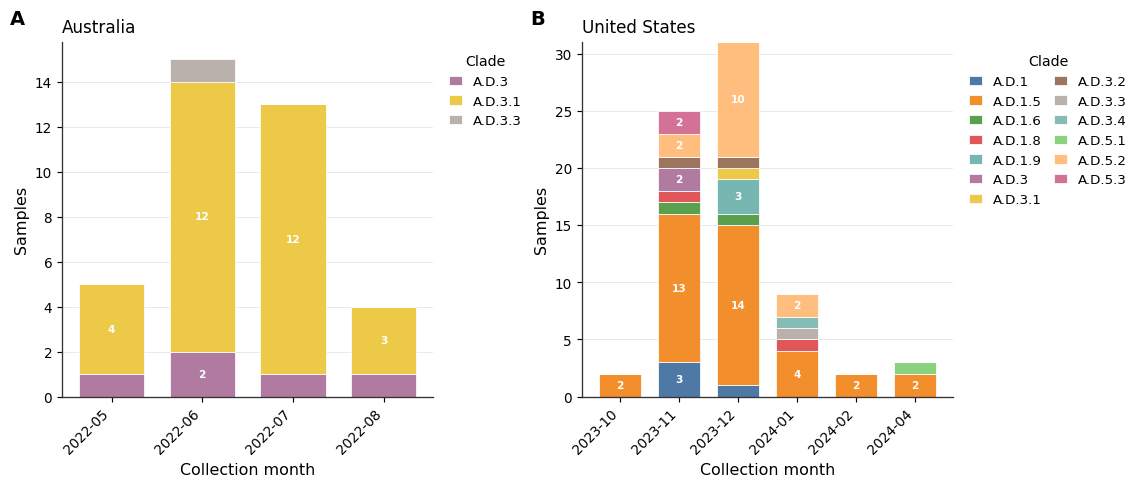

In [5]:
fig, paths = au.draw_sample_composition(month_clade, FIG_DIR)
display(paths)
plt.show()
